# `GridInterpolator`: 1D, 2D, 3D examples

Brief tour of `dynestyx.observation.GridInterpolator` (see `dynestyx/observation.py`,
`tests/test_observation.py`). All three examples use `boundary="constant", fill_value=0.0`
-- query points outside the grid return exactly 0.

In [1]:
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

from dynestyx.observation import GridInterpolator, interpolation_observation_model

## 1D

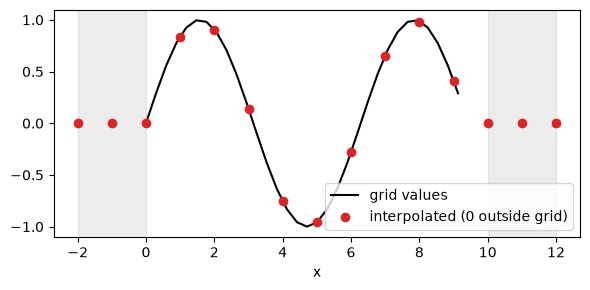

In [8]:
nx = 32
x_axis = jnp.linspace(0.0, 3*jnp.pi, nx, endpoint=False)
values_1d = jnp.sin(x_axis)

query_1d = jnp.linspace(-2.0, 12.0, 15)[:, None]  # extends past the grid on both sides

interp_1d = GridInterpolator((x_axis,), query_1d, method="linear", boundary="constant", fill_value=0.0)
result_1d = interp_1d(values_1d)

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(x_axis, values_1d, color="black", label="grid values")
ax.scatter(query_1d[:, 0], result_1d, color="tab:red", zorder=5, label="interpolated (0 outside grid)")
ax.axvspan(-2, 0, color="gray", alpha=0.15)
ax.axvspan(10, 12, color="gray", alpha=0.15)
ax.legend()
ax.set_xlabel("x")
plt.tight_layout()
plt.show()

`interpolation_observation_model` builds a ready-to-use `LinearGaussianObservation`
directly from the same arguments:

In [9]:
obs_model = interpolation_observation_model(
    (x_axis,), query_1d, R=0.01 * jnp.eye(query_1d.shape[0]),
    method="linear", boundary="constant", fill_value=0.0,
)
print(obs_model(values_1d, None, 0.0).mean[:5])  # matches result_1d[:5]

[0.         0.         0.         0.83264982 0.90262231]


## 2D

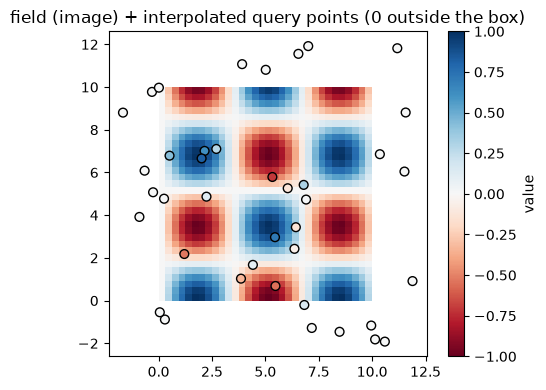

In [11]:
nx, ny = 32, 32
x_axis = jnp.linspace(0.0, 3*jnp.pi, nx, endpoint=False)
y_axis = jnp.linspace(0.0, 3*jnp.pi, ny, endpoint=False)
xs, ys = jnp.meshgrid(x_axis, y_axis, indexing="ij")
values_2d = (jnp.sin(xs) * jnp.cos(ys)).reshape(-1)

query_2d = jr.uniform(jr.PRNGKey(0), (40, 2), minval=-2.0, maxval=12.0)

interp_2d = GridInterpolator((x_axis, y_axis), query_2d, method="linear", boundary="constant", fill_value=0.0)
result_2d = interp_2d(values_2d)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(values_2d.reshape(nx, ny).T, origin="lower", extent=(0, 10, 0, 10), cmap="RdBu", vmin=-1, vmax=1)
ax.scatter(query_2d[:, 0], query_2d[:, 1], c=result_2d, cmap="RdBu", vmin=-1, vmax=1, edgecolor="black", s=40)
fig.colorbar(im, ax=ax, label="value")
ax.set_title("field (image) + interpolated query points (0 outside the box)")
plt.tight_layout()
plt.show()

## 3D

In [13]:
nx, ny, nz = 16, 16, 16
x_axis = jnp.linspace(0.0, 2*jnp.pi, nx, endpoint=False)
y_axis = jnp.linspace(0.0, 2*jnp.pi, ny, endpoint=False)
z_axis = jnp.linspace(0.0, 2*jnp.pi, nz, endpoint=False)
xs, ys, zs = jnp.meshgrid(x_axis, y_axis, z_axis, indexing="ij")


def f_3d(x, y, z):
    return jnp.sin(x) + jnp.cos(y) + 0.1 * z


values_3d = f_3d(xs, ys, zs).reshape(-1)

query_3d = jr.uniform(jr.PRNGKey(1), (30, 3), minval=-1.0, maxval=6.0)
interp_3d = GridInterpolator((x_axis, y_axis, z_axis), query_3d, method="linear", boundary="constant", fill_value=0.0)
result_3d = interp_3d(values_3d)

true_3d = f_3d(query_3d[:, 0], query_3d[:, 1], query_3d[:, 2])
in_domain = jnp.all((query_3d >= 0.0) & (query_3d < 5.0), axis=1)
print("max abs error, in-domain points:", float(jnp.max(jnp.abs(result_3d[in_domain] - true_3d[in_domain]))))

# A point well outside the domain on every axis: no valid grid point is nearby, so the
# result is exactly 0. (Points only just outside on one axis instead blend a real grid
# value with 0, per the "constant" boundary's straddling behavior -- see test_observation.py.)
far_outside_interp = GridInterpolator(
    (x_axis, y_axis, z_axis), jnp.array([[-3.0, -3.0, -3.0]]), boundary="constant", fill_value=0.0
)
print("interpolated value far outside the domain (exactly 0):", float(far_outside_interp(values_3d)[0]))

max abs error, in-domain points: 0.024200793877321658
interpolated value far outside the domain (exactly 0): 0.0
